<a href="https://colab.research.google.com/github/daveveed/Geo-Data-Science/blob/main/Raster_representation_and_Xarray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Creating a simple raster layer using numpy
To get a better sense of how the raster data looks like, we can start by creating a simple two-dimensional array in Python using numpy. In the following, we will modify the raster layer to represent a simple terrain that has a hill in the middle of the grid. We do this by setting higher values in the center while the other values are represented with value 0. Let’s start by importing the numpy and matplotlib library which we use for visualizing our data:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Creating a simple 2D raster layer (a 2D array) with 10x10 array can be done easily by using a numpy method .zeros() with fills the cells (pixels) with zeros. Each zero represents a default pixel value (e.g. 0 elevation). You can think of this as an empty raster grid:

In [2]:
raster_layer = np.zeros((10,10))
raster_layer

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [3]:
raster_layer[4:7, 4:7] = 5
raster_layer[5,5] = 10
raster_layer

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  5.,  5.,  5.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  5., 10.,  5.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  5.,  5.,  5.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])

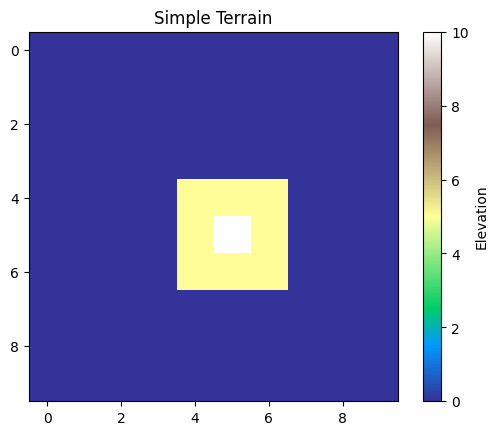

In [7]:
plt.imshow(raster_layer, cmap='terrain')
plt.colorbar(label='Elevation')
plt.title('Simple Terrain')
plt.show()

## Key xarray datastructures: Dataset and DataArray
The two fundamental data structures provided by the xarray library are DataArray and Dataset (Figure below). Both of them build upon and extend the strengths of numpy and pandas libraries. The DataArray is a labeled N-dimensional array that is similar to pandas.Series but works with raster data (stored as numpy arrays). The Dataset then again is a multi-dimensional in-memory array database that contains multiple DataArray objects. In addition to the variables containing the observations of a given phenomena, you also have the x and y coordinates of the observations stored in separate layers, as well as metadata providing relevant information about your data, such as Coordinate Reference System and/or time. Thus, a Dataset containing raster data is very similar to geopandas.GeoDataFrame and actually various xarray operations can feel very familiar if you have learned the basics of pandas and geopandas


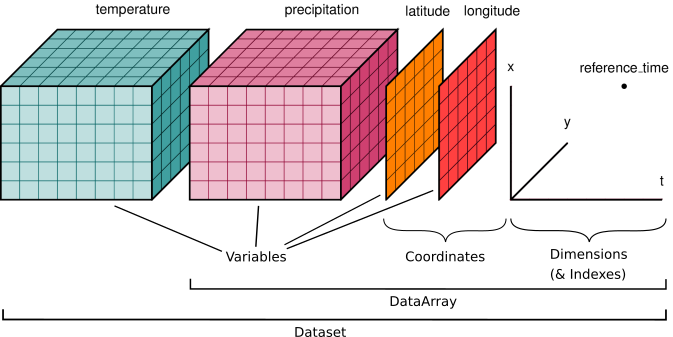


## Reading a file into Dataset
We start by investigating a simple elevation dataset using xarray that represents a Digital Elevation Model (DEM) of Kilimanjaro area in Tanzania. To read a raster data file (such as GeoTIFF) into xarray, we can use the .open_dataset() function. Here, we read a .tif file directly from a cloud storage space that we have created for this book. By importing the rioxarray library, we can extend the functionalities of the xarray and use the engine="rasterio" parameter when reading the data. This is beneficial because it supports various GIS functionalities related to Coordinate Reference System management and metadata that would not be available otherwise. We can for example specify that the masked parameter is True which will take into consideration possible NoData values in the data and mask them out by setting the NoData values as NaN:

In [1]:
import xarray as xr
import rioxarray as rxr

In [9]:
!pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.7 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [3]:
bucket_url = "https://a3s.fi/swift/v1/AUTH_0914d8aff9684df589041a759b549fc2/PythonGIS"
url = bucket_url + "/elevation/kilimanjaro/ASTGTMV003_S03E036_dem.tif"
# url = "data/temp/kilimanjaro_elevation.tif"

data = xr.open_dataset(url, engine="rasterio", masked=True)
data

<xarray.Dataset> Size: 52MB
Dimensions:      (band: 1, x: 3601, y: 3601)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 29kB 36.0 36.0 36.0 36.0 ... 37.0 37.0 37.0 37.0
  * y            (y) float64 29kB -2.0 -2.0 -2.001 -2.001 ... -2.999 -3.0 -3.0
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 52MB ...

In [4]:
type(data)

xarray.core.dataset.Dataset

Because our Dataset only consists of a single band (i.e. the elevation values), it might make sense to reduce the dimensions of our dataset by dropping the band attribute because it is not really providing any useful information for us. We can subset our data and remove a specific dimension from our data by using the .squeeze() method. In the following, we drop the "band" dimension:

In [5]:
data = data.squeeze('band', drop=True)
data

<xarray.Dataset> Size: 52MB
Dimensions:      (x: 3601, y: 3601)
Coordinates:
  * x            (x) float64 29kB 36.0 36.0 36.0 36.0 ... 37.0 37.0 37.0 37.0
  * y            (y) float64 29kB -2.0 -2.0 -2.001 -2.001 ... -2.999 -3.0 -3.0
    spatial_ref  int64 8B ...
Data variables:
    band_data    (y, x) float32 52MB ...

 An alternative way to deal with this issue is to use band_as_variable=True parameter directly when reading the raster file with xr.open_dataset():

##Renaming data variables
To make the data more intuitive to use, we can also change the name of the data variable from band_data into elevation. In this way, it is more evident what our data is about. We can easily change the name of an attibute by using the .rename() method as follows which wants a dictionary with syntax {"old_name": "new_name"}:

In [6]:
data = data.rename({'band_data': 'elevation'})
data

<xarray.Dataset> Size: 52MB
Dimensions:      (x: 3601, y: 3601)
Coordinates:
  * x            (x) float64 29kB 36.0 36.0 36.0 36.0 ... 37.0 37.0 37.0 37.0
  * y            (y) float64 29kB -2.0 -2.0 -2.001 -2.001 ... -2.999 -3.0 -3.0
    spatial_ref  int64 8B ...
Data variables:
    elevation    (y, x) float32 52MB ...

## Plotting

Text(0.5, 1.0, 'Elevation in m')

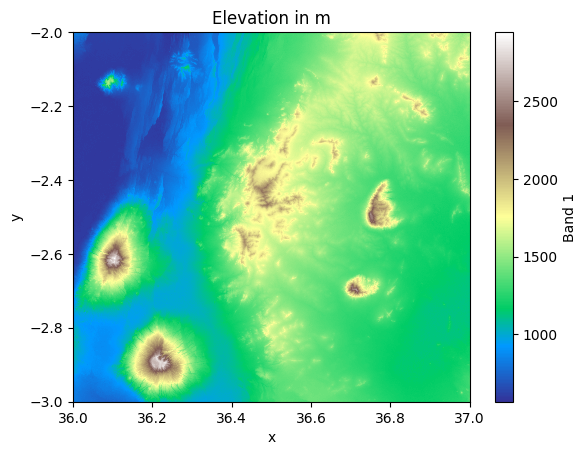

In [9]:
import matplotlib.pyplot as plt

mesh = data['elevation'].plot(cmap='terrain')

plt.title('Elevation in m')

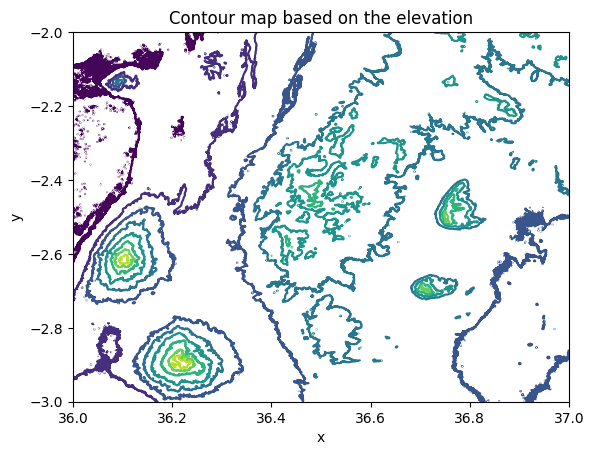

In [10]:
contours = data["elevation"].plot.contour()
plt.title("Contour map based on the elevation");

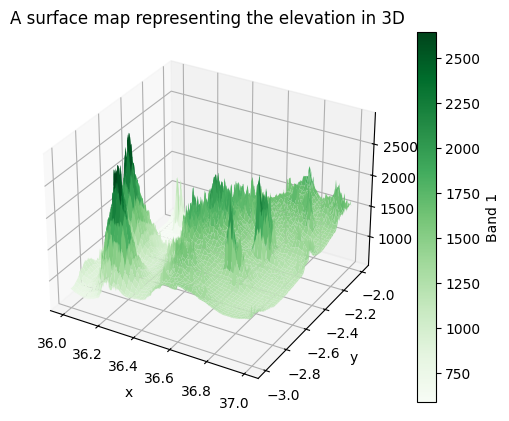

In [11]:
surface = data["elevation"].plot.surface(cmap="Greens")
plt.title("A surface map representing the elevation in 3D");

##Extracting basic raster dataset properties
Now as we have explored our data visually, it is good to continue by examining the basic properties of the data, as well as by calculating summary statistics out of the data, such as the minimum, maximum, or mean values of your data. To extract this information from your Dataset, xarray provides very similar functionalities as pandas to compute some basic statistics out of your data. For instance, we can easily extract the maximum elevation of our data by calling .max() method:

In [12]:
data['elevation'].max()

<xarray.DataArray 'elevation' ()> Size: 8B
array(2943.)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    Band_1:         Band 1
    AREA_OR_POINT:  Area
    long_name:      Band 1

As we see, this produces quite a lot of information because xarray returns an DataArray as a result by default. When exploring the output, we can see that the single value in the array is 2943 which is the highest point in our data. However, typically it would be more useful to get a numerical value as a result when doing operations like these. Luckily, it is easy to extract the actual number from the data by adding .item() after the command. The .item() method returns the xarray.Dataset element as a regular Python scalar value which is more similar to what e.g. pandas returns when you call the .max() or .min(), as demonstrated below:

In [13]:
data['elevation'].max().item()

2943.0

In addition to the summary statistics, we can explore some of the basic properties of our raster data. Majority of the geographic data related properties of a raster Dataset can be accessed via .rio accessor. An accessor is a method or attribute added to an existing data structure, such as a DataArray or Dataset in xarray, to provide specialized functionality. Accessors extend the capabilities of the base object without modifying its core structure. Via the .rio accessor we can explore various attributes of our data, such as the .shape, .width or .height:

In [14]:
data.rio.shape

(3601, 3601)

In [15]:
data.rio.width

3601

In [16]:
data.rio.height

3601

In [17]:
data.rio.resolution()

(0.000277777777777778, -0.000277777777777778)

In [18]:
data.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [19]:
data.rio.bounds()

(35.9998611111111, -3.000138888888889, 37.000138888888884, -1.99986111111111)

In [20]:
data['elevation'].rio.nodata

The .rio.nodata returns the value how the NaN value is represented in our xarray.DataArray. As we can see, the NaN value is represented with numpy library’s nan. However, in many cases, the NoData value in a given raster file is actually coded with a specific numerical value that is a clear outlier compared to the rest of the data, such as -9999 or 9999. To find out what value has been used in the raster file to code the NoData value, we can use rio.encoded_nodata which returns the NoData value as it is represented in the actual source data:

In [22]:
print(data['elevation'].rio.encoded_nodata)

None


It is important to deal with possible NaN values in the data, because otherwise the NoData values would be presented as actual values in the dataset (i.e. elevation). In our case, we dealt with the NaN values already when reading the data into xarray with xr.open_dataset() by specifying masked=True. This ensured that all values with number 9999 in the raster were transformed into numpy.nan values. This ensures that they do not influence any of the calculations when using the data but they are properly treated as data that does not exist. For example, the maximum value that we extracted earlier from the data was 2943, not 9999 which would be the case unless we mask out the NaN values when reading the data.

If a given dataset contains NoData values (it does not necessarily contain any NoData), the metadata of the dataset should always contain information about how the NoData values are encoded. With some raster files, you can also search for the NoData value by checking the .attrs attribute that might include information about NoData and is returned as a Python dictionary. The information about NoData can be can be stored with different keys, and you should look for values stored in keys, such as _FillValue, missing_value, fill_value or nodata. In our raster file, this metadata has not been stored as part of the file, and thus, we cannot access the .attrs attribute:

In [23]:
data.dtypes #radiometric resolution (bit depth)

Frozen({'elevation': dtype('float32')})

## creating new data variable

In [24]:
min_elevation = data["elevation"].min().item()

# Calculate the relief
data["relative_height"] = data["elevation"] - min_elevation
data

<xarray.Dataset> Size: 104MB
Dimensions:          (x: 3601, y: 3601)
Coordinates:
  * x                (x) float64 29kB 36.0 36.0 36.0 36.0 ... 37.0 37.0 37.0
  * y                (y) float64 29kB -2.0 -2.0 -2.001 ... -2.999 -3.0 -3.0
    spatial_ref      int64 8B 0
Data variables:
    elevation        (y, x) float32 52MB 826.0 826.0 ... 1.301e+03 1.305e+03
    relative_height  (y, x) float32 52MB 258.0 258.0 255.0 ... 733.0 733.0 737.0

In [25]:
data.data_vars #to get all the variables in the dataset

Data variables:
    elevation        (y, x) float32 52MB 826.0 826.0 ... 1.301e+03 1.305e+03
    relative_height  (y, x) float32 52MB 258.0 258.0 255.0 ... 733.0 733.0 737.0

## GeoTiff

In [26]:
import os

In [27]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
  os.mkdir(data_folder)

if not os.path.exists(output_folder):
  os.mkdir(output_folder)

In [28]:
elevation_output = 'elevation.tif'
height_output = 'height.tif'

data['elevation'].rio.to_raster(os.path.join(data_folder, elevation_output))
data['relative_height'].rio.to_raster(os.path.join(data_folder, height_output))

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3030: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
  return runner(coro)


In [30]:
xr.open_dataset(os.path.join(data_folder, elevation_output), engine="rasterio", masked=True)

<xarray.Dataset> Size: 52MB
Dimensions:      (band: 1, x: 3601, y: 3601)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 29kB 36.0 36.0 36.0 36.0 ... 37.0 37.0 37.0 37.0
  * y            (y) float64 29kB -2.0 -2.0 -2.001 -2.001 ... -2.999 -3.0 -3.0
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 52MB ...

## cloud oprimised geotiff COG

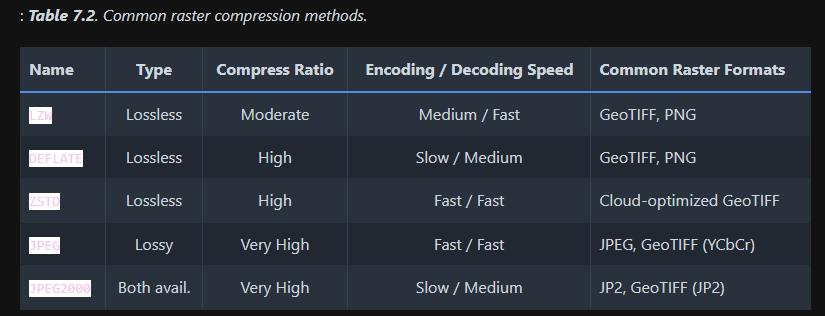

In [31]:
cog_tif = 'elevattion_cog.tif'


In [32]:
data['elevation'].rio.to_raster(os.path.join(output_folder, cog_tif),
                                driver='COG', compress='LZW')

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3030: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
  return runner(coro)


In [33]:
xr.open_dataset(os.path.join(output_folder, cog_tif), engine='rasterio', masked=True)

<xarray.Dataset> Size: 52MB
Dimensions:      (band: 1, x: 3601, y: 3601)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 29kB 36.0 36.0 36.0 36.0 ... 37.0 37.0 37.0 37.0
  * y            (y) float64 29kB -2.0 -2.0 -2.001 -2.001 ... -2.999 -3.0 -3.0
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 52MB ...

##netCDF
With netCDF format you can write (and read) a whole xarray.Dataset at a time which can be very convenient especially when you have multiple relevant variables that you want to store. When saving a Dataset to netCDF, you can use the .to_netcdf() method of xarray:

In [34]:
netcdf_fn = "kilimanjaro_dataset.nc"
netcdf_fp = os.path.join(output_folder, netcdf_fn)
data.to_netcdf(netcdf_fp)

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: SerializationWarning: saving variable elevation with floating point data as an integer dtype without any _FillValue to use for NaNs
  exec(code_obj, self.user_global_ns, self.user_ns)


In [35]:
ds = xr.open_dataset(netcdf_fp, decode_coords='all')
ds

<xarray.Dataset> Size: 156MB
Dimensions:          (y: 3601, x: 3601)
Coordinates:
  * y                (y) float64 29kB -2.0 -2.0 -2.001 ... -2.999 -3.0 -3.0
  * x                (x) float64 29kB 36.0 36.0 36.0 36.0 ... 37.0 37.0 37.0
    spatial_ref      int64 8B ...
Data variables:
    elevation        (y, x) float64 104MB ...
    relative_height  (y, x) float32 52MB ...